# ImageNet Classification with Deep Convolutional Neural Networks

Authors: Alex Krizhevsky, Ilya Sutskever, Geoffrey E. Hinton

Year: 2012 (published in the proceedings of NeurIPS / NIPS)

# Decoding The Research Paper

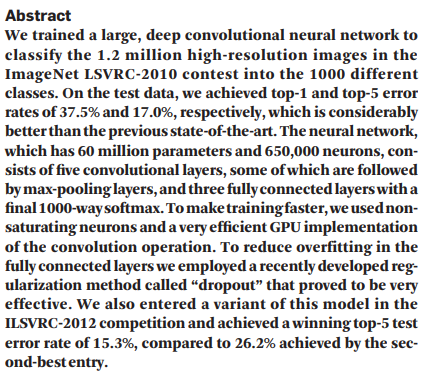

# Datasets

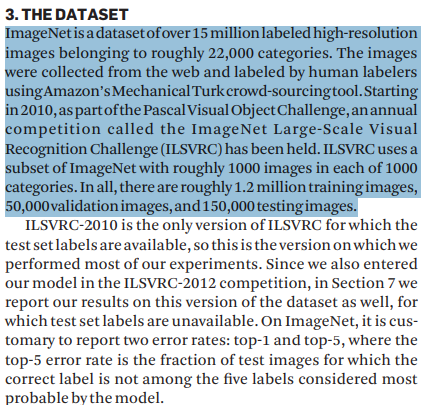



*   Variable resolution Images
*   Constant Input dimensionality
*   Downsamples to 256x256 (rectangula Image)
*   No Pre processing (except substracting the mean activity over training set from each pixel)
*   Centered raw RGB values of the pixels




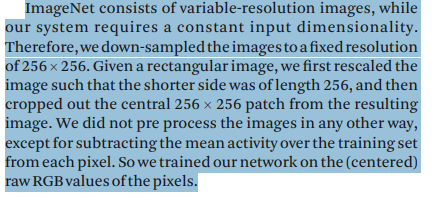

# GPUs

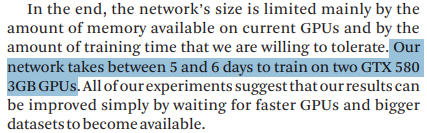

Architecture:

*   Five Convolutional and three fully connected
*   Relu (instead of tanh)

Saturating nonlinearities
*   Tanh and Sigmoid are called saturating nonlinearities, meaning their output squashes into a narrow range:

*  Sigmoid: outputs between 0 and 1.
*  tanh: outputs between -1 and 1.
*  Problem: When the input is very positive or very negative, the gradient becomes almost zero (vanishing gradient problem).
*  This makes training slow, especially in deep networks.

Non-saturating Linearlities:

*  f(x) = max(0,x), non saturating for positive inputs
*  Faster Training



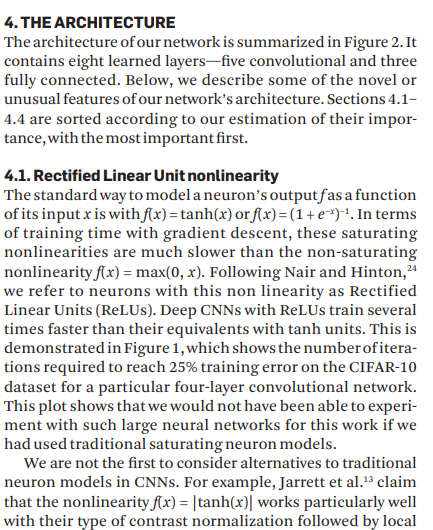



*   Two GPUs
*   Choosing the pattern of connectivity is a problem for cross-validation



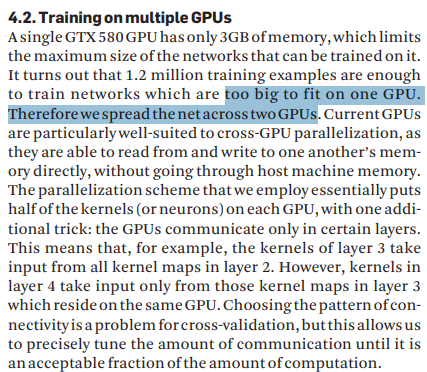

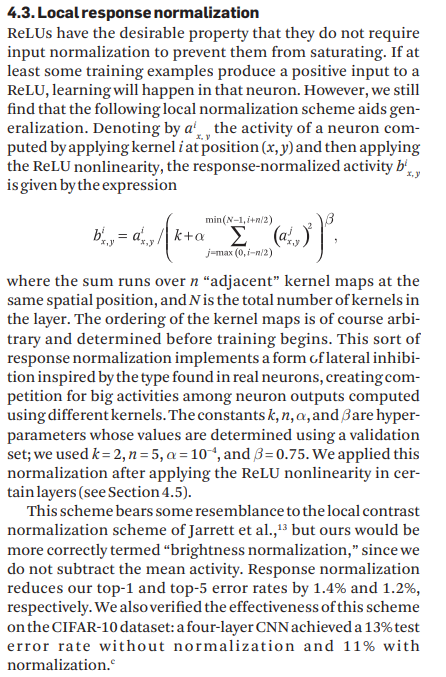

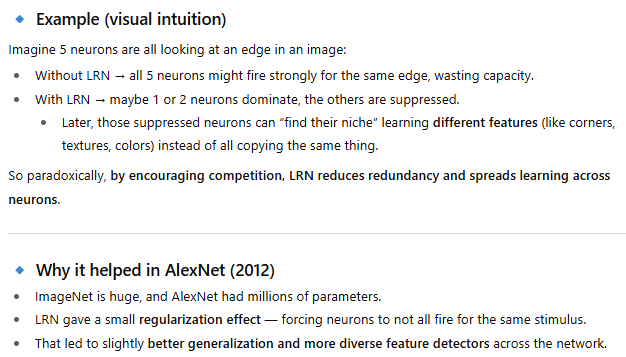




*   In AlexNet, use pooling windows that overlap.
*   Example: 3×3 pooling window with stride 2
*   Window size = 3×3
*   Stride = 2 → the windows overlap, since 3 > 2.
*   Now each pixel may contribute to multiple pooling regions.

Why AlexNet used overlapping pooling

1. Stronger regularization: Overlapping pooling prevents overfitting by adding a bit of redundancy (a single activation influences multiple pooled outputs).

2. Better generalization: In experiments, AlexNet found overlapping pooling reduced the error rate slightly compared to non-overlapping pooling.

3. Smoother feature extraction: Helps capture features more robustly, since boundaries between pooling regions are less harsh.

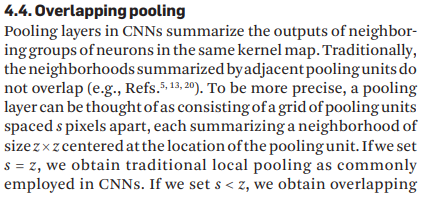

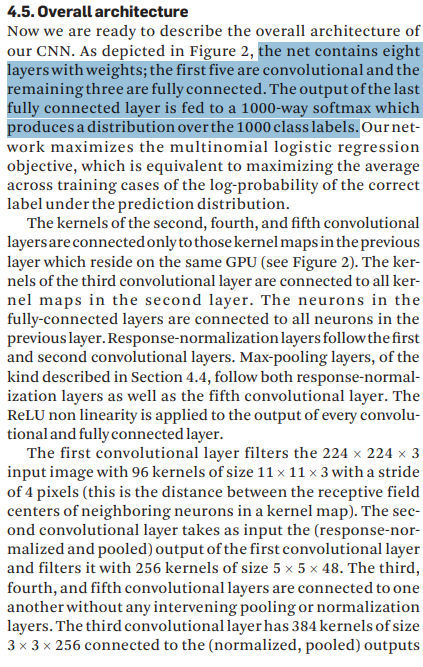

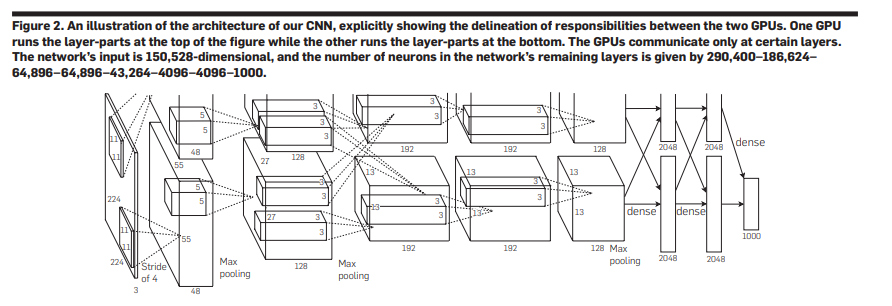

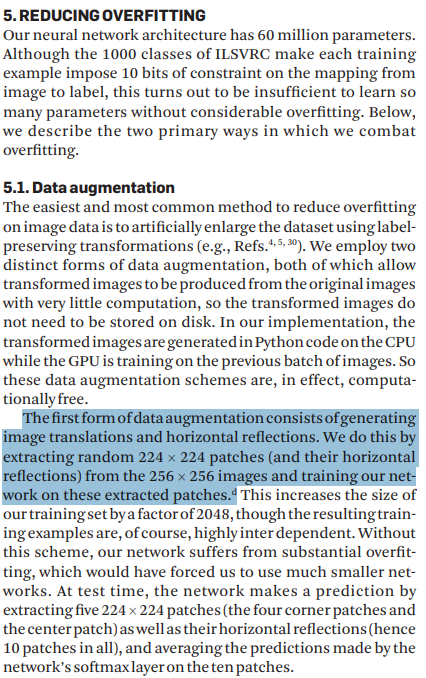

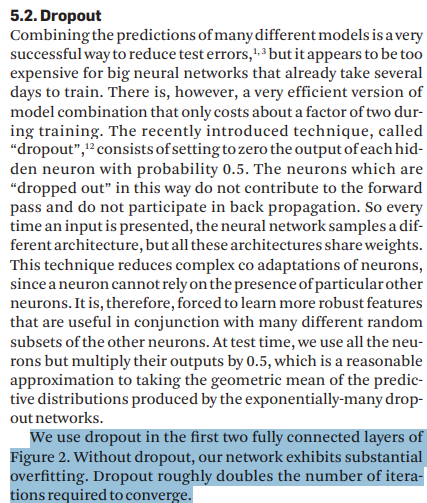

Facts About Alexnet:

Architectural Innovations

1. Deep architecture – 8 layers (5 convolutional + 3 fully connected), deeper than most CNNs before.

2. Large network size – ~60 million parameters, very large for its time.

3. ReLU activation – Used Rectified Linear Units instead of sigmoid/tanh → much faster training.

4. Overlapping pooling – Max pooling windows overlapped (3×3, stride 2) instead of disjoint → reduced overfitting.

5. Local Response Normalization (LRN) – Inspired by biological lateral inhibition, encouraged competition between neurons.

6. Dropout regularization – Used dropout (p=0.5) in fully connected layers to reduce overfitting.

7. Large receptive fields – First convolution layer used an 11×11 kernel (stride 4), capturing large image features.

8. Multiple GPUs for training – Split the model across 2 GPUs due to memory limits, a novel strategy in 2012.

🔹 Training Strategies

9. Data augmentation – Used image translations, horizontal flips, and patch extractions to expand dataset.

10. Color jittering – Slightly altered intensities of RGB channels for robustness.

11. Stochastic Gradient Descent (SGD) with momentum – Optimizer with momentum = 0.9, weight decay = 0.0005.

12. Mini-batch size of 128 – Balanced efficiency and stability of training.

13. Weight initialization – Carefully initialized to stabilize deep training.

14. Learning rate schedule – Reduced learning rate manually when validation error stopped improving.

🔹 Practical Breakthroughs

15. First large-scale CNN on ImageNet – Applied to 1.2 million images, unlike previous CNNs on small datasets (MNIST, CIFAR-10).

16. Top-5 error reduction – Achieved 15.3% vs previous best ~26% → huge leap in accuracy.

17. Proved scalability of deep CNNs – Showed large, deep networks can train and generalize well.

18. Showcased GPU power – Demonstrated that GPUs could enable training of massive neural networks in days instead of months.

19. AlexNet has 7 hidden layers (5 convolutional + 2 fully connected).

20. The third FC layer is the output layer for ImageNet classification (1000 categories).

Using device: cpu
Parameters: total=58,322,314  trainable=58,322,314
=== AlexNet forward pass: layer-by-layer shapes & explanations ===
conv1    -> (1, 96, 56, 56) | Conv1: 96×11×11, stride 4, pad 2 → big initial receptive field.
relu1    -> (1, 96, 56, 56) | ReLU: non-linearity; faster than tanh/sigmoid.
lrn1     -> (1, 96, 56, 56) | LRN: local response normalization (historical competition across channels).
pool1    -> (1, 96, 27, 27) | MaxPool 3×3 / stride 2 (overlapping) → gentle spatial downsampling.
conv2    -> (1, 256, 27, 27) | Conv2: 256×5×5, pad 2.
relu2    -> (1, 256, 27, 27) | ReLU.
lrn2     -> (1, 256, 27, 27) | LRN again (replaced by BatchNorm in modern CNNs).
pool2    -> (1, 256, 13, 13) | MaxPool 3×3 / stride 2.
conv3    -> (1, 384, 13, 13) | Conv3: 384×3×3, pad 1.
relu3    -> (1, 384, 13, 13) | ReLU.
conv4    -> (1, 384, 13, 13) | Conv4: 384×3×3, pad 1.
relu4    -> (1, 384, 13, 13) | ReLU.
conv5    -> (1, 256, 13, 13) | Conv5: 256×3×3, pad 1.
relu5    -> (1, 256, 13, 1

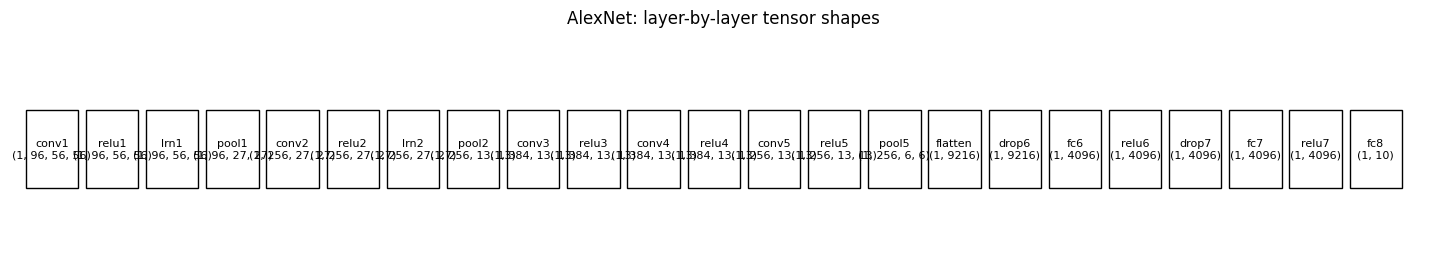

Using subset: train=2000  val=400


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[train] batch -> images (64, 3, 227, 227)  labels (64,)
    - Images resized to 227×227 to match AlexNet
    - Normalized with ImageNet mean/std (common practice)
    - CIFAR-10 has 10 classes; FC8 outputs 10 logits
[valid] batch -> images (64, 3, 227, 227)  labels (64,)
    - Images resized to 227×227 to match AlexNet
    - Normalized with ImageNet mean/std (common practice)
    - CIFAR-10 has 10 classes; FC8 outputs 10 logits
[epoch 1/1] train loss 2.5335 acc 0.1010 | val loss 2.2764 acc 0.2125
Best val acc: 0.2125


In [3]:
# === AlexNet (paper-style) — Colab single cell, no argparse, no file writes ===
# What you get:
# 1) Model: ReLU, LRN, overlapping max-pool (3x3, s=2), 5 conv + 3 fc (last fc=logits)
# 2) Forward tracer: prints layer-by-layer shapes + explanation; draws a diagram inline
# 3) CIFAR-10 tiny run: auto-download, resize to 227, rich prints

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from collections import OrderedDict

# ---------------- AlexNet (paper-style) ----------------
class AlexNetPaper(nn.Module):
    """
    AlexNet (Krizhevsky et al., 2012)
    - ReLU after each conv/FC (non-saturating)
    - LRN after early convs (historical; largely obsolete now)
    - Overlapping MaxPool (3x3, stride 2)
    - 5 conv + 3 FC (last FC = classifier logits)
    - No BatchNorm (arrived later, 2015)
    """
    def __init__(self, num_classes=1000):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=2, bias=True),  # conv1
            nn.ReLU(inplace=True),                                             # relu1
            nn.LocalResponseNorm(size=5, alpha=1e-4, beta=0.75, k=2),          # lrn1
            nn.MaxPool2d(kernel_size=3, stride=2),                             # pool1

            nn.Conv2d(96, 256, kernel_size=5, padding=2, bias=True),           # conv2
            nn.ReLU(inplace=True),                                             # relu2
            nn.LocalResponseNorm(size=5, alpha=1e-4, beta=0.75, k=2),          # lrn2
            nn.MaxPool2d(kernel_size=3, stride=2),                             # pool2

            nn.Conv2d(256, 384, kernel_size=3, padding=1, bias=True),          # conv3
            nn.ReLU(inplace=True),                                             # relu3
            nn.Conv2d(384, 384, kernel_size=3, padding=1, bias=True),          # conv4
            nn.ReLU(inplace=True),                                             # relu4
            nn.Conv2d(384, 256, kernel_size=3, padding=1, bias=True),          # conv5
            nn.ReLU(inplace=True),                                             # relu5
            nn.MaxPool2d(kernel_size=3, stride=2),                             # pool5
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),                                                   # drop6
            nn.Linear(256 * 6 * 6, 4096), nn.ReLU(inplace=True),               # fc6, relu6
            nn.Dropout(0.5),                                                   # drop7
            nn.Linear(4096, 4096), nn.ReLU(inplace=True),                      # fc7, relu7
            nn.Linear(4096, num_classes)                                       # fc8
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0.)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

# ---------------- Forward tracer & diagram ----------------
def trace_forward_and_plot(model, input_size=(1,3,227,227)):
    """Run a dummy forward pass, print shapes w/ explanations, and plot a diagram inline."""
    model.eval()
    x = torch.randn(*input_size)

    # Friendly names in order:
    names = [
        "conv1","relu1","lrn1","pool1",
        "conv2","relu2","lrn2","pool2",
        "conv3","relu3","conv4","relu4","conv5","relu5","pool5",
        "drop6","fc6","relu6","drop7","fc7","relu7","fc8"
    ]
    mods = [
        model.features[0], model.features[1], model.features[2], model.features[3],
        model.features[4], model.features[5], model.features[6], model.features[7],
        model.features[8], model.features[9], model.features[10], model.features[11],
        model.features[12], model.features[13], model.features[14],
        model.classifier[0], model.classifier[1], model.classifier[2],
        model.classifier[3], model.classifier[4], model.classifier[5],
        model.classifier[6],
    ]

    explanations = {
        "conv1": "Conv1: 96×11×11, stride 4, pad 2 → big initial receptive field.",
        "relu1": "ReLU: non-linearity; faster than tanh/sigmoid.",
        "lrn1":  "LRN: local response normalization (historical competition across channels).",
        "pool1": "MaxPool 3×3 / stride 2 (overlapping) → gentle spatial downsampling.",
        "conv2": "Conv2: 256×5×5, pad 2.",
        "relu2": "ReLU.",
        "lrn2":  "LRN again (replaced by BatchNorm in modern CNNs).",
        "pool2": "MaxPool 3×3 / stride 2.",
        "conv3": "Conv3: 384×3×3, pad 1.",
        "relu3": "ReLU.",
        "conv4": "Conv4: 384×3×3, pad 1.",
        "relu4": "ReLU.",
        "conv5": "Conv5: 256×3×3, pad 1.",
        "relu5": "ReLU.",
        "pool5": "MaxPool 3×3 / stride 2 → ~6×6 spatial before FCs.",
        "drop6": "Dropout p=0.5 (regularization; active in train mode).",
        "fc6":   "FC6: 4096 units.",
        "relu6": "ReLU.",
        "drop7": "Dropout p=0.5.",
        "fc7":   "FC7: 4096 units.",
        "relu7": "ReLU.",
        "fc8":   "FC8: logits (e.g., 1000 for ImageNet or 10 for CIFAR-10).",
    }

    # Register forward hooks to capture shapes
    records = []
    def make_hook(name):
        def hook(m, inp, out):
            shape = tuple(out[0].shape) if isinstance(out, tuple) else tuple(out.shape)
            records.append((name, shape))
        return hook
    handles = [m.register_forward_hook(make_hook(n)) for n, m in zip(names, mods)]

    # Run partial forward to capture flatten point too
    with torch.no_grad():
        feat = model.features(x)
        flat = torch.flatten(feat, 1)
        # Insert flatten into the records visually just after pool5:
        # We'll add it manually; hooks already captured pool5.
        # Then pass through classifier to capture the rest.
        out = model.classifier(flat)

    # Clean up hooks
    for h in handles:
        h.remove()

    # Print step-by-step
    print("=== AlexNet forward pass: layer-by-layer shapes & explanations ===")
    # Insert an explicit flatten record after pool5
    # Find index of pool5 to place flatten next
    idx_pool5 = [i for i,(n,_) in enumerate(records) if n=="pool5"]
    if idx_pool5:
        insert_at = idx_pool5[0] + 1
        records.insert(insert_at, ("flatten", tuple(flat.shape)))
        explanations["flatten"] = "Flatten to vector (256×6×6 = 9216) → ready for FC layers."

    for name, shape in records:
        note = explanations.get(name, "")
        print(f"{name:<8} -> {shape} | {note}")

    # Draw simple diagram inline
    labels = [f"{n}\n{t}" for n,t in records]
    fig, ax = plt.subplots(figsize=(max(10, len(labels)*0.8), 2.8))
    ax.axis('off')
    x, w, h, dx = 0.3, 1.0, 0.8, 1.15
    for lab in labels:
        rect = plt.Rectangle((x, 0.6), w, h, fill=False)  # no specific colors
        ax.add_patch(rect)
        ax.text(x+w/2, 0.6+h/2, lab, ha='center', va='center', fontsize=8)
        x += dx
    ax.set_xlim(0, x+0.5); ax.set_ylim(0, 2.2)
    plt.title("AlexNet: layer-by-layer tensor shapes")
    plt.show()

    return records

# ---------------- Data pipeline (CIFAR-10) ----------------
def build_transforms(img_size=227, train=True):
    if train:
        return transforms.Compose([
            transforms.Resize(int(img_size * 256/227)),
            transforms.RandomResizedCrop(img_size, scale=(0.7, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(0.1, 0.1, 0.1, 0.02),  # approximates paper's color jitter/PCA trick
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
        ])
    else:
        return transforms.Compose([
            transforms.Resize(int(img_size * 256/227)),
            transforms.CenterCrop(img_size),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
        ])

def describe_batch(images, labels, tag):
    print(f"[{tag}] batch -> images {tuple(images.shape)}  labels {tuple(labels.shape)}")
    print("    - Images resized to 227×227 to match AlexNet")
    print("    - Normalized with ImageNet mean/std (common practice)")
    print("    - CIFAR-10 has 10 classes; FC8 outputs 10 logits")

# ---------------- Train / Eval ----------------
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total=0; correct=0; runloss=0.0
    for step,(x,y) in enumerate(loader):
        if step==0: describe_batch(x,y,"train")
        x,y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits,y)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        runloss += loss.item()*x.size(0)
        pred = logits.argmax(1); correct += (pred==y).sum().item(); total += y.size(0)
    return runloss/total, correct/total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total=0; correct=0; runloss=0.0
    for step,(x,y) in enumerate(loader):
        if step==0: describe_batch(x,y,"valid")
        x,y = x.to(device), y.to(device)
        logits = model(x); loss = criterion(logits,y)
        runloss += loss.item()*x.size(0)
        pred = logits.argmax(1); correct += (pred==y).sum().item(); total += y.size(0)
    return runloss/total, correct/total

def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Parameters: total={total:,}  trainable={trainable:,}")

# ---------------- Run everything ----------------
# Config block you can tweak directly in Colab:
IMG_SIZE   = 227
EPOCHS     = 1           # increase for real training
BATCH_SIZE = 64
SUBSET     = 2000        # set 0 for full CIFAR-10 train set
LR         = 0.01
MOMENTUM   = 0.9
WEIGHT_DECAY = 5e-4
NUM_CLASSES   = 10       # CIFAR-10

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 1) Build model and run forward trace + diagram
alex = AlexNetPaper(num_classes=NUM_CLASSES).to(device)
count_params(alex)
_ = trace_forward_and_plot(alex, input_size=(1,3,IMG_SIZE,IMG_SIZE))

# 2) CIFAR-10 tiny run
train_tf = build_transforms(IMG_SIZE, True)
test_tf  = build_transforms(IMG_SIZE, False)

train_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_tf)
test_set  = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_tf)

if SUBSET and SUBSET > 0:
    train_set = Subset(train_set, range(SUBSET))
    test_subset = min(1000, max(200, SUBSET//5))
    test_set  = Subset(test_set, range(test_subset))
    print(f"Using subset: train={len(train_set)}  val={len(test_set)}")
else:
    print(f"Using full CIFAR-10: train={len(train_set)}  val={len(test_set)}")

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(alex.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)

best = 0.0
for epoch in range(EPOCHS):
    tr_loss, tr_acc = train_one_epoch(alex, train_loader, criterion, optimizer, device)
    va_loss, va_acc = evaluate(alex, test_loader, criterion, device)
    print(f"[epoch {epoch+1}/{EPOCHS}] train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {va_loss:.4f} acc {va_acc:.4f}")
    best = max(best, va_acc)
print(f"Best val acc: {best:.4f}")


**What this script demonstrates:**

ReLU (nonlinearity): every nn.ReLU → faster training than tanh/sigmoid.

LRN (obsolete today): nn.LocalResponseNorm(...) after Conv1/Conv2.

Overlapping pooling: nn.MaxPool2d(kernel_size=3, stride=2).

Deep CNN: 5 conv + 3 FC layers (last FC = classifier).

Dropout regularization: nn.Dropout(p=0.5) before FC layers.

Large early kernels/stride: Conv1 11x11, stride 4.

Data augmentation: RandomResizedCrop, HorizontalFlip, ColorJitter.

SGD + momentum + weight decay: optim.SGD(...) with momentum=0.9, weight_decay=5e-4.

Learning-rate schedule: MultiStepLR to mimic manual drops.

2-GPU training: optional nn.DataParallel(model) if multiple GPUs present.

227×227 input: set via --imgsz 227 and transforms.

# Other Architectures

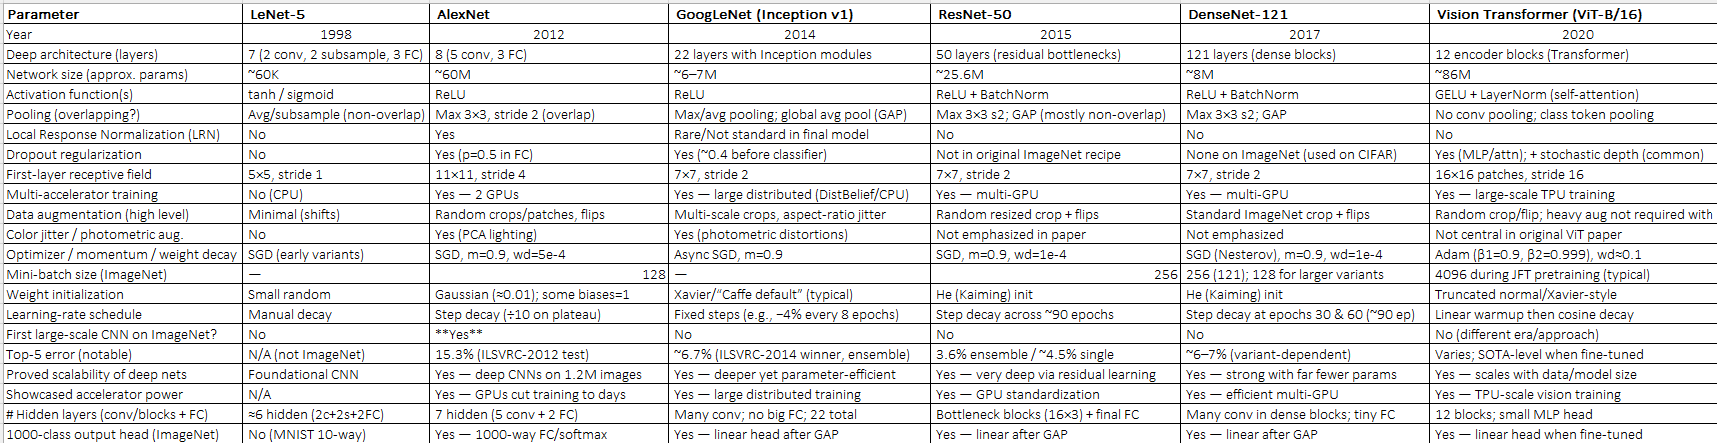